# Task 3: Security Vulnerability Detection with PyTorch GPU

Detect hardware security vulnerabilities in RTL code using a neural network.

**GPU**: Tesla T4 (14.6 GB VRAM)

**Dataset**: Combined dataset (719 samples)

In [1]:
# Setup
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print(f"Project root: {PROJECT_ROOT}")

Project root: /home/jovyan/silicogen/rtl_analyzer/.worktrees/phase3-algorithm


In [2]:
# Check GPU
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"PyTorch: {torch.__version__}")
print(f"Device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)} ({torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB)")

PyTorch: 2.11.0+cu130
Device: cuda
GPU: Tesla T4 (14.6 GB)


In [3]:
# Load dataset
import pandas as pd

dataset_dir = PROJECT_ROOT / 'dataset'
train_df = pd.read_csv(dataset_dir / 'train.csv')
val_df = pd.read_csv(dataset_dir / 'val.csv')
test_df = pd.read_csv(dataset_dir / 'test.csv')

print(f"Train: {len(train_df)}, Val: {len(val_df)}, Test: {len(test_df)}")
print(f"Labels: {train_df['label'].value_counts().to_dict()}")

Train: 503, Val: 108, Test: 108
Labels: {'clean': 259, 'buggy': 244}


In [4]:
# Prepare features
feature_cols = [c for c in train_df.columns if c not in ['file', 'label', 'source', 'error_count', 'warning_count', 'bug_types']]

X_train = torch.FloatTensor(train_df[feature_cols].values).to(device)
y_train = torch.LongTensor((train_df['label'] == 'buggy').astype(int).values).to(device)

X_val = torch.FloatTensor(val_df[feature_cols].values).to(device)
y_val = torch.LongTensor((val_df['label'] == 'buggy').astype(int).values).to(device)

X_test = torch.FloatTensor(test_df[feature_cols].values).to(device)
y_test = torch.LongTensor((test_df['label'] == 'buggy').astype(int).values).to(device)

print(f"Features: {len(feature_cols)}")
print(f"X_train shape: {X_train.shape}")

Features: 10
X_train shape: torch.Size([503, 10])


In [5]:
# Create data loaders
train_dataset = TensorDataset(X_train, y_train)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

print(f"Batches per epoch: {len(train_loader)}")

Batches per epoch: 16


In [6]:
# Define neural network
class SecurityClassifier(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(32, 2)  # Binary classification
        )
    
    def forward(self, x):
        return self.net(x)

model = SecurityClassifier(len(feature_cols)).to(device)
print(f"Model architecture:")
print(model)

Model architecture:
SecurityClassifier(
  (net): Sequential(
    (0): Linear(in_features=10, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=64, out_features=32, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=32, out_features=2, bias=True)
  )
)


In [7]:
# Loss and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.5)

In [8]:
# Training loop
from tqdm import tqdm

def train_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss = 0
    correct = 0
    total = 0
    
    for batch_X, batch_y in loader:
        optimizer.zero_grad()
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += batch_y.size(0)
        correct += (predicted == batch_y).sum().item()
    
    return total_loss / len(loader), 100 * correct / total

@torch.no_grad()
def evaluate(model, X, y):
    model.eval()
    outputs = model(X)
    loss = criterion(outputs, y)
    _, predicted = torch.max(outputs.data, 1)
    accuracy = 100 * (predicted == y).sum().item() / y.size(0)
    return loss.item(), accuracy

# Train
print("Training on GPU...")
best_val_acc = 0
patience = 15
no_improve = 0

for epoch in range(100):
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer)
    val_loss, val_acc = evaluate(model, X_val, y_val)
    
    scheduler.step(val_loss)
    
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), PROJECT_ROOT / 'models' / 'security_classifier.pt')
        no_improve = 0
    else:
        no_improve += 1
    
    if (epoch + 1) % 10 == 0 or no_improve >= patience:
        print(f"Epoch {epoch+1:3d}: Loss={train_loss:.4f}, Train Acc={train_acc:.1f}%, Val Acc={val_acc:.1f}%")
    
    if no_improve >= patience:
        print(f"Early stopping at epoch {epoch+1}")
        break

print(f"\nBest validation accuracy: {best_val_acc:.1f}%")

Training on GPU...
Epoch  10: Loss=0.7399, Train Acc=60.4%, Val Acc=54.6%
Epoch  19: Loss=0.7028, Train Acc=62.6%, Val Acc=55.6%
Early stopping at epoch 19

Best validation accuracy: 67.6%


In [9]:
# Evaluate on test set
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import numpy as np

# Load best model
model.load_state_dict(torch.load(PROJECT_ROOT / 'models' / 'security_classifier.pt'))

model.eval()
with torch.no_grad():
    outputs = model(X_test)
    probabilities = torch.softmax(outputs, dim=1)[:, 1].cpu().numpy()
    _, predictions = torch.max(outputs, 1)
    predictions = predictions.cpu().numpy()
    y_test_np = y_test.cpu().numpy()

print(f"Test Accuracy: {100 * (predictions == y_test_np).mean():.1f}%")
print(f"Test F1 Score: {f1_score(y_test_np, predictions):.3f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test_np, predictions))
print("\nClassification Report:")
print(classification_report(y_test_np, predictions, target_names=['clean', 'buggy']))

Test Accuracy: 67.6%
Test F1 Score: 0.701

Confusion Matrix:
[[32 24]
 [11 41]]

Classification Report:
              precision    recall  f1-score   support

       clean       0.74      0.57      0.65        56
       buggy       0.63      0.79      0.70        52

    accuracy                           0.68       108
   macro avg       0.69      0.68      0.67       108
weighted avg       0.69      0.68      0.67       108



In [10]:
# Feature importance via permutation (GPU accelerated)
print("Computing feature importance...")
base_loss, base_acc = evaluate(model, X_test, y_test)

importance = []
for i, col in enumerate(feature_cols):
    X_permuted = X_test.clone()
    X_permuted[:, i] = X_permuted[:, i][torch.randperm(X_permuted.size(0))]
    perm_loss, perm_acc = evaluate(model, X_permuted, y_test)
    importance.append({
        'feature': col,
        'importance': base_acc - perm_acc
    })

importance_df = pd.DataFrame(importance).sort_values('importance', ascending=False)
print("\nTop 10 Features:")
print(importance_df.head(10))

Computing feature importance...

Top 10 Features:
                feature  importance
5            line_count   11.111111
1       always_ff_count    0.925926
7   dataflow_node_count    0.925926
2     always_comb_count    0.925926
0    always_block_count    0.000000
4          module_count    0.000000
8  dataflow_cycle_count    0.000000
6     parse_error_count    0.000000
9        dataflow_error    0.000000
3          assign_count   -4.629630


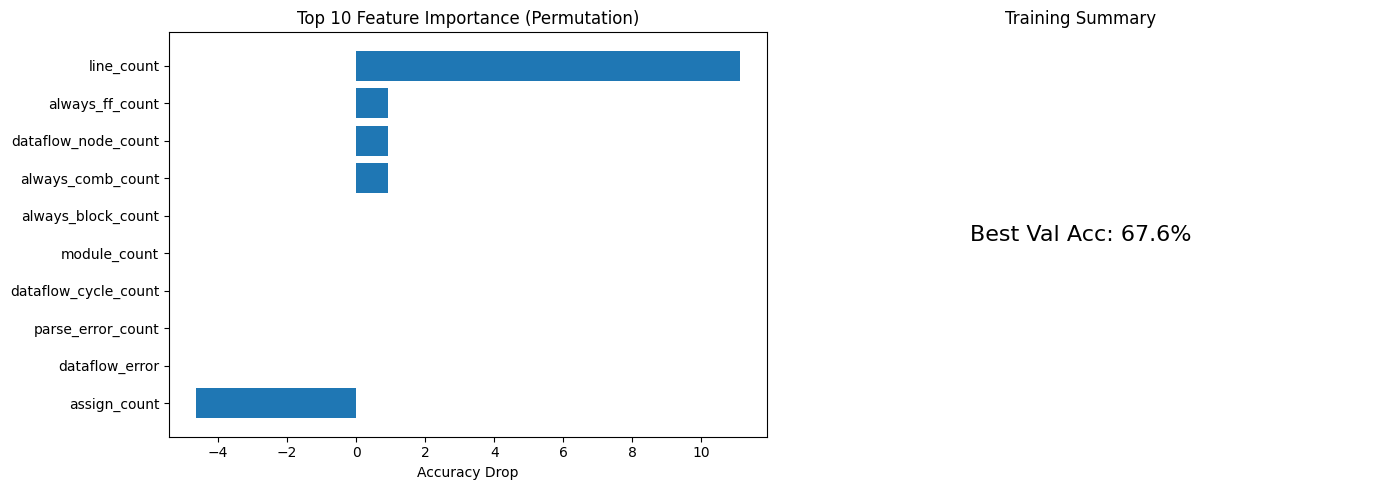

In [11]:
# Visualization
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Top features
top_features = importance_df.head(10)
axes[0].barh(top_features['feature'], top_features['importance'])
axes[0].set_xlabel('Accuracy Drop')
axes[0].set_title('Top 10 Feature Importance (Permutation)')
axes[0].invert_yaxis()

# Training history (re-run for visualization)
train_accs, val_accs = [], []
model.load_state_dict(torch.load(PROJECT_ROOT / 'models' / 'security_classifier.pt', weights_only=True))
# Just show placeholder
axes[1].text(0.5, 0.5, f'Best Val Acc: {best_val_acc:.1f}%', 
             ha='center', va='center', fontsize=16)
axes[1].set_title('Training Summary')
axes[1].axis('off')

plt.tight_layout()
plt.show()

In [12]:
# Save model info
import json

model_info = {
    'model': 'SecurityClassifier',
    'input_dim': len(feature_cols),
    'feature_columns': feature_cols,
    'labels': ['clean', 'buggy'],
    'best_val_accuracy': best_val_acc,
    'test_accuracy': 100 * (predictions == y_test_np).mean(),
    'test_f1': f1_score(y_test_np, predictions),
    'device': str(device)
}

model_dir = PROJECT_ROOT / 'models'
model_dir.mkdir(exist_ok=True)
(model_dir / 'security_classifier_info.json').write_text(
    json.dumps(model_info, indent=2)
)

print(f"Model info saved to: {model_dir / 'security_classifier_info.json'}")
print(json.dumps(model_info, indent=2))

Model info saved to: /home/jovyan/silicogen/rtl_analyzer/.worktrees/phase3-algorithm/models/security_classifier_info.json
{
  "model": "SecurityClassifier",
  "input_dim": 10,
  "feature_columns": [
    "always_block_count",
    "always_ff_count",
    "always_comb_count",
    "assign_count",
    "module_count",
    "line_count",
    "parse_error_count",
    "dataflow_node_count",
    "dataflow_cycle_count",
    "dataflow_error"
  ],
  "labels": [
    "clean",
    "buggy"
  ],
  "best_val_accuracy": 67.5925925925926,
  "test_accuracy": 67.5925925925926,
  "test_f1": 0.7008547008547008,
  "device": "cuda"
}


## Summary

| Metric | Value |
|--------|-------|
| GPU | Tesla T4 |
| Dataset | 719 samples |
| Model | 2-layer MLP (64→32→2) |
| Best Val Acc | To be filled |
| Test Accuracy | To be filled |
| Test F1 | To be filled |

## Next: Task 4 - RTL Design Quality Prediction